# Kummer Kernel: Exact vs RFF Approximation

This notebook demonstrates the Random Fourier Feature (RFF) approximation for the Kummer kernel.

## Kernel Definition

The Kummer kernel is defined using Kummer's confluent hypergeometric function M (also known as $_1F_1$):
$$k(x, x') = M\left(\beta, \beta + \gamma, -\|x - x'\|^\alpha\right)$$

where:
- $\alpha \in (0, 2]$ controls the exponent
- $\beta > 0$ is the first parameter
- $\gamma > 0$ is the second parameter

### Spectral Mixing Distribution
The mixing distribution R follows: $R \sim \text{Beta}(\beta, \gamma)$

In [1]:
using Pkg
Pkg.activate("..")

  Activating project at `~/GeneralizedRFF.jl`


In [2]:
using GeneralizedRandomFourierFeatures
using KernelFunctions
using KernelFunctions: ColVecs
using AbstractGPs
using Random
using LinearAlgebra
using Plots
gr()

Random.seed!(42)

TaskLocalRNG()

## 1. Kernel Profile Comparison

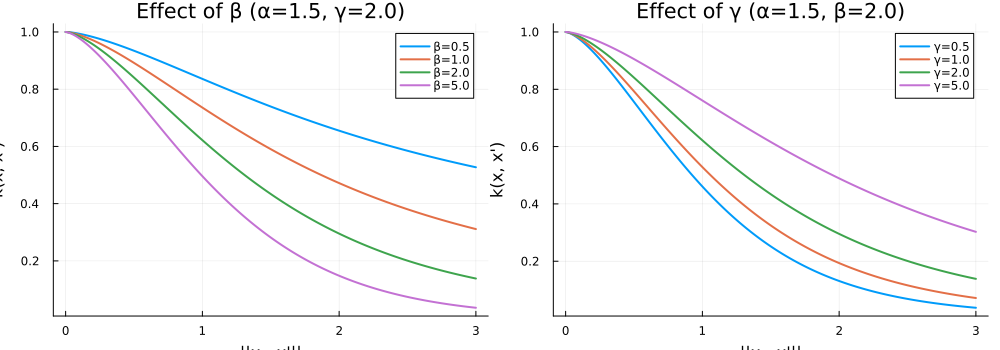

In [3]:
# Compare different parameter combinations
x_range = range(0, 3, length=200)

# Vary beta with fixed alpha, gamma
p_beta = plot(title="Effect of β (α=1.5, γ=2.0)", xlabel="||x - x'||", ylabel="k(x, x')")
for β in [0.5, 1.0, 2.0, 5.0]
    k = KummerKernel(α=1.5, β=β, γ=2.0)
    y_k = [k([0.0], [x]) for x in x_range]
    plot!(p_beta, x_range, y_k, label="β=$β", linewidth=2)
end

# Vary gamma with fixed alpha, beta
p_gamma = plot(title="Effect of γ (α=1.5, β=2.0)", xlabel="||x - x'||", ylabel="k(x, x')")
for γ in [0.5, 1.0, 2.0, 5.0]
    k = KummerKernel(α=1.5, β=2.0, γ=γ)
    y_k = [k([0.0], [x]) for x in x_range]
    plot!(p_gamma, x_range, y_k, label="γ=$γ", linewidth=2)
end

plot(p_beta, p_gamma, layout=(1, 2), size=(1000, 350))

## 2. Kernel Matrix Comparison (Heatmap)

In [4]:
# Define kernel
k = KummerKernel(α=1.5, β=2.0, γ=1.5)
println("Kernel: ", k)

Kernel: Kummer Kernel (α = 1.5, β = 2.0, γ = 1.5, metric = Distances.Euclidean(0.0))


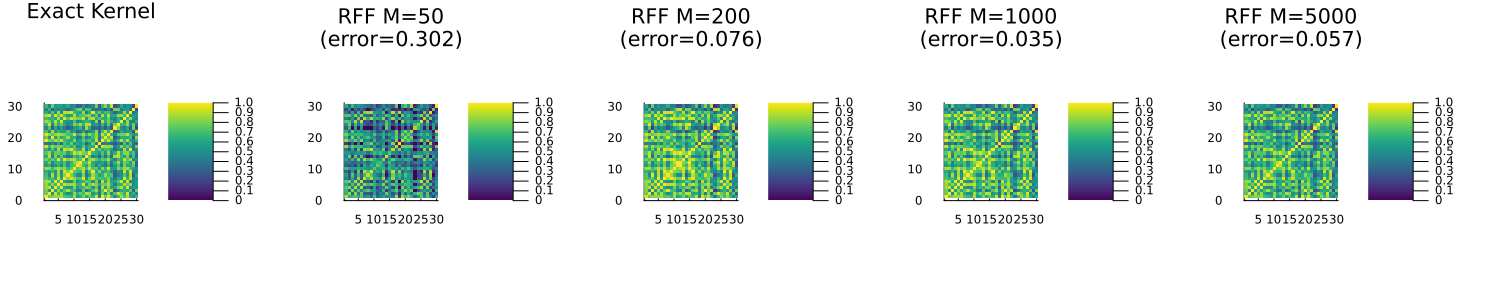

In [5]:
# Generate test data
n = 30
X = [rand(2) * 2 for _ in 1:n]

# Exact kernel matrix
K_exact = kernelmatrix(k, X)

# RFF approximation with different M values
M_values = [50, 200, 1000, 5000]

plots = [heatmap(K_exact, title="Exact Kernel", c=:viridis, aspect_ratio=1, clim=(0, 1))]

for M in M_values
    K_approx = rff_kernelmatrix(MersenneTwister(123), k, X, M)
    rel_error = norm(K_exact - K_approx) / norm(K_exact)
    push!(plots, heatmap(K_approx, title="RFF M=$M\n(error=$(round(rel_error, digits=3)))", 
                         c=:viridis, aspect_ratio=1, clim=(0, 1)))
end

plot(plots..., layout=(1, 5), size=(1500, 300))

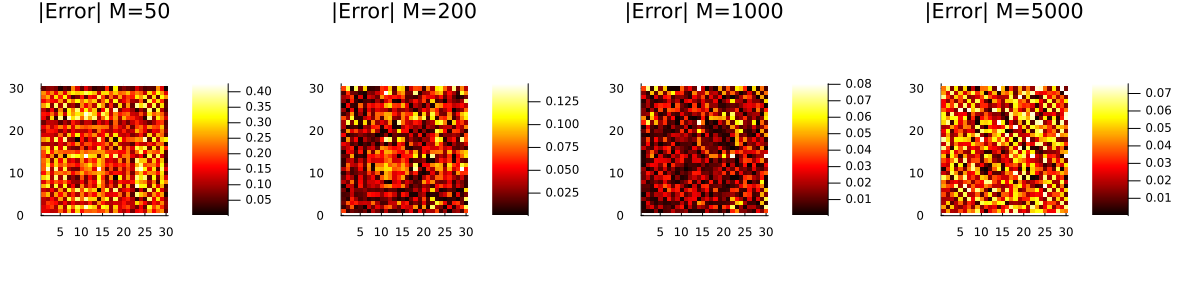

In [6]:
# Error difference heatmaps
error_plots = []
for M in M_values
    K_approx = rff_kernelmatrix(MersenneTwister(123), k, X, M)
    K_diff = abs.(K_exact - K_approx)
    push!(error_plots, heatmap(K_diff, title="|Error| M=$M", c=:hot, aspect_ratio=1))
end

plot(error_plots..., layout=(1, 4), size=(1200, 300))

## 3. Convergence Analysis

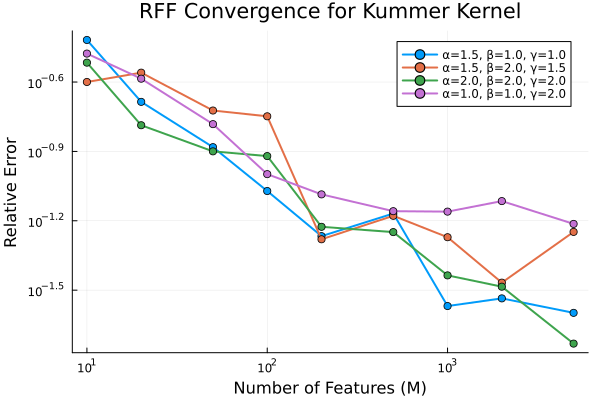

In [7]:
# Analyze convergence for different parameter combinations
M_range = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]

param_sets = [
    (1.5, 1.0, 1.0),
    (1.5, 2.0, 1.5),
    (2.0, 2.0, 2.0),
    (1.0, 1.0, 2.0)
]

p_conv = plot(title="RFF Convergence for Kummer Kernel",
              xlabel="Number of Features (M)", ylabel="Relative Error",
              xscale=:log10, yscale=:log10, legend=:topright)

for (α, β, γ) in param_sets
    k_param = KummerKernel(α=α, β=β, γ=γ)
    K_exact_param = kernelmatrix(k_param, X)
    
    errors = Float64[]
    for M in M_range
        K_approx = rff_kernelmatrix(MersenneTwister(42), k_param, X, M)
        rel_error = norm(K_exact_param - K_approx) / norm(K_exact_param)
        push!(errors, rel_error)
    end
    
    plot!(p_conv, M_range, errors, marker=:circle, label="α=$α, β=$β, γ=$γ", linewidth=2)
end

p_conv

## 4. 1D Gaussian Process Comparison

In [8]:
# RFF approximation for GP
function rff_gp_predict(k, X_train, y_train, X_test, M; noise=0.1)
    rng = MersenneTwister(42)
    d = length(first(X_train))
    basis = sample_generalized_rff_basis(rng, k, d, M)
    
    Phi_train_mat = hcat(X_train...)
    Phi_test_mat = hcat(X_test...)
    
    features_train = basis(ColVecs(Phi_train_mat))
    features_test = basis(ColVecs(Phi_test_mat))
    
    Phi_train = hcat([features_train[i] for i in 1:length(X_train)]...)'
    Phi_test = hcat([features_test[i] for i in 1:length(X_test)]...)'
    
    n, m = size(Phi_train)
    A = Phi_train' * Phi_train + noise^2 * I(m)
    w_mean = A \ (Phi_train' * y_train)
    
    m_pred = Phi_test * w_mean
    Sigma_w = noise^2 * inv(A)
    v_pred = [Phi_test[i, :]' * Sigma_w * Phi_test[i, :] + noise^2 for i in 1:size(Phi_test, 1)]
    
    return m_pred, sqrt.(v_pred)
end

rff_gp_predict (generic function with 1 method)

In [9]:
# Generate 1D data
n_train = 10
x_train = sort(rand(n_train) * 4 .- 2)
y_train = sin.(2 * x_train) .+ 0.2 * randn(n_train)

x_test = range(-2.5, 2.5, length=200)

X_train = [[x] for x in x_train]
X_test = [[x] for x in x_test]

# Exact GP
k_1d = KummerKernel(α=1.5, β=2.0, γ=1.5)
f_exact = GP(k_1d)
fx_exact = f_exact(X_train, 0.1)
p_exact = posterior(fx_exact, y_train)

m_exact = mean(p_exact(X_test))
s_exact = sqrt.(var(p_exact(X_test)))

200-element Vector{Float64}:
 0.9550491418920589
 0.9529651673852512
 0.9507857026440575
 0.9485067095308688
 0.9461240105859028
 0.9436332865927336
 0.941030074277773
 0.9383097641591961
 0.9354675985614512
 0.9324986698121358
 0.9293979186386543
 0.9261601327827023
 0.9227799458512371
 ⋮
 0.5160192173744838
 0.5334277662849432
 0.5503322022844006
 0.5667397028447239
 0.5826580704440469
 0.5980955643701846
 0.6130607813863477
 0.6275625694904404
 0.6416099643182391
 0.655212141182963
 0.6683783780046836
 0.6811180258876741

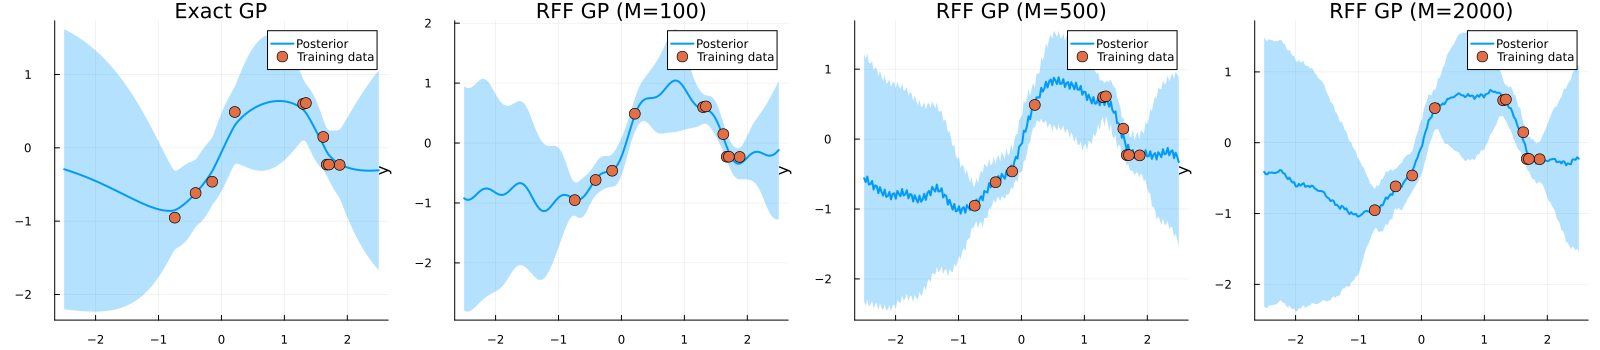

In [10]:
# Compare GP predictions
p1 = plot(title="Exact GP", xlabel="x", ylabel="y", legend=:topright)
plot!(p1, x_test, m_exact, ribbon=2*s_exact, fillalpha=0.3, label="Posterior", linewidth=2)
scatter!(p1, x_train, y_train, label="Training data", markersize=6)

M_vals = [100, 500, 2000]
rff_plots = []
for M in M_vals
    m_rff, s_rff = rff_gp_predict(k_1d, X_train, y_train, X_test, M)
    p = plot(title="RFF GP (M=$M)", xlabel="x", ylabel="y", legend=:topright)
    plot!(p, x_test, m_rff, ribbon=2*s_rff, fillalpha=0.3, label="Posterior", linewidth=2)
    scatter!(p, x_train, y_train, label="Training data", markersize=6)
    push!(rff_plots, p)
end

plot(p1, rff_plots..., layout=(1, 4), size=(1600, 350))

## 5. 2D Gaussian Process Comparison

In [11]:
# Generate 2D data
n_train_2d = 30
X_train_2d = [rand(2) * 4 .- 2 for _ in 1:n_train_2d]
y_train_2d = [sin(x[1]) * cos(x[2]) + 0.1 * randn() for x in X_train_2d]

# Test grid
x1_range = range(-2.5, 2.5, length=40)
x2_range = range(-2.5, 2.5, length=40)
X_test_2d = [[x1, x2] for x1 in x1_range for x2 in x2_range]

1600-element Vector{Vector{Float64}}:
 [-2.5, -2.5]
 [-2.5, -2.371794871794872]
 [-2.5, -2.2435897435897436]
 [-2.5, -2.1153846153846154]
 [-2.5, -1.9871794871794872]
 [-2.5, -1.858974358974359]
 [-2.5, -1.7307692307692308]
 [-2.5, -1.6025641025641026]
 [-2.5, -1.4743589743589745]
 [-2.5, -1.3461538461538463]
 [-2.5, -1.2179487179487178]
 [-2.5, -1.0897435897435896]
 [-2.5, -0.9615384615384616]
 ⋮
 [2.5, 1.0897435897435896]
 [2.5, 1.2179487179487178]
 [2.5, 1.3461538461538463]
 [2.5, 1.4743589743589745]
 [2.5, 1.6025641025641026]
 [2.5, 1.7307692307692308]
 [2.5, 1.858974358974359]
 [2.5, 1.9871794871794872]
 [2.5, 2.1153846153846154]
 [2.5, 2.2435897435897436]
 [2.5, 2.371794871794872]
 [2.5, 2.5]

In [12]:
# Exact GP for 2D
k_2d = KummerKernel(α=1.5, β=2.0, γ=1.5)
f_exact_2d = GP(k_2d)
fx_exact_2d = f_exact_2d(X_train_2d, 0.1)
p_exact_2d = posterior(fx_exact_2d, y_train_2d)

m_exact_2d = mean(p_exact_2d(X_test_2d))
m_exact_grid = reshape(m_exact_2d, length(x1_range), length(x2_range))

40×40 Matrix{Float64}:
 -0.0371202  -0.0318898  -0.025875   …  -0.158478   -0.135697   -0.113036
 -0.0483321  -0.043072   -0.0368664     -0.151893   -0.126175   -0.101426
 -0.062444   -0.057366   -0.0511425     -0.136604   -0.108382   -0.0822814
 -0.0799719  -0.0753754  -0.0693866     -0.110034   -0.0804465  -0.0543084
 -0.101446   -0.0977455  -0.0923575     -0.0697444  -0.0408961  -0.0166726
 -0.127371   -0.125124   -0.120861   …  -0.0144715   0.010714    0.0306131
 -0.15816    -0.158094   -0.155683       0.0547403   0.0732464   0.0863862
 -0.194056   -0.197061   -0.197459       0.134438    0.143876    0.148273
 -0.235034   -0.242125   -0.246477       0.219587    0.218421    0.212896
 -0.280716   -0.292952   -0.302477       0.304073    0.291784    0.276289
 -0.330327   -0.348703   -0.364541   …   0.380587    0.358588    0.334568
 -0.38268    -0.408042   -0.431143       0.442283    0.414706    0.384897
 -0.436218   -0.46919    -0.500271       0.488548    0.459261    0.42631
  ⋮        

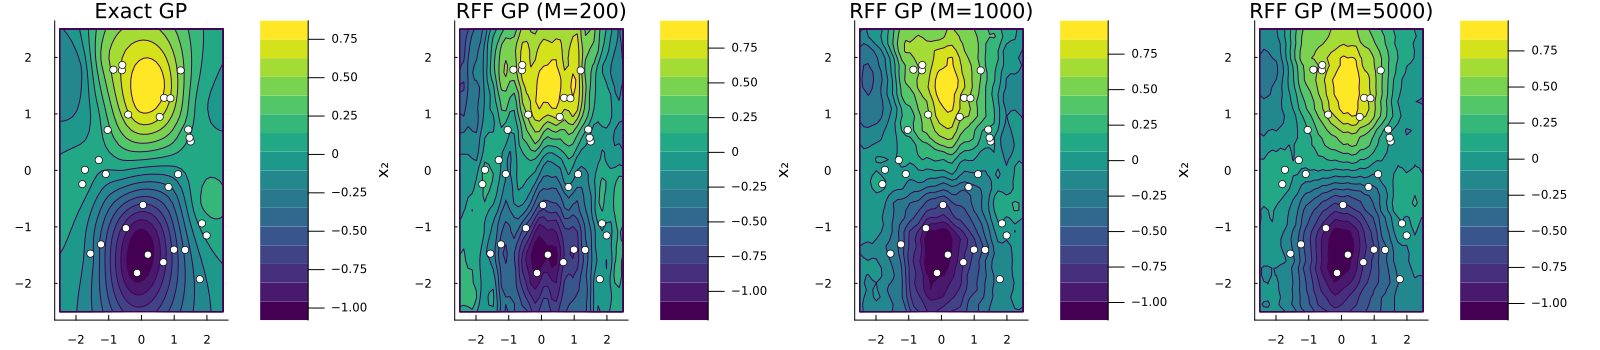

In [13]:
# Plot 2D comparison
p_exact_plot = contourf(x1_range, x2_range, m_exact_grid', 
                        title="Exact GP", xlabel="x₁", ylabel="x₂", c=:viridis)
scatter!(p_exact_plot, [x[1] for x in X_train_2d], [x[2] for x in X_train_2d], 
         c=:white, markersize=4, label="")

rff_2d_plots = [p_exact_plot]
for M in [200, 1000, 5000]
    m_rff_2d, _ = rff_gp_predict(k_2d, X_train_2d, y_train_2d, X_test_2d, M)
    m_rff_grid = reshape(m_rff_2d, length(x1_range), length(x2_range))
    
    p_rff = contourf(x1_range, x2_range, m_rff_grid', 
                     title="RFF GP (M=$M)", xlabel="x₁", ylabel="x₂", c=:viridis)
    scatter!(p_rff, [x[1] for x in X_train_2d], [x[2] for x in X_train_2d], 
             c=:white, markersize=4, label="")
    push!(rff_2d_plots, p_rff)
end

plot(rff_2d_plots..., layout=(1, 4), size=(1600, 350))

## Summary

The Kummer kernel RFF approximation:
- Uses Beta(β, γ) as the spectral mixing distribution
- The kernel shape is controlled by three parameters (α, β, γ)
- RFF approximation converges well with increasing M
- Both 1D and 2D GP regression are well approximated